В этом ноутбуке мы попытаемся прогнозировать данные по транзакциям с использованием библиотеки пророк

Загрузим библиотеки и данные

In [74]:
# Load libraries
import numpy as np
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import pandas as pd
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 70)
import plotly.offline as py
import plotly.graph_objs as go
py.init_notebook_mode()

from prophet import Prophet

%time df_transactions = pd.read_csv('data/transactions.csv')
%time df_holidays_events = pd.read_csv('data/holidays_events.csv')

print('Data and libraries are loaded.')

CPU times: user 25 ms, sys: 8.23 ms, total: 33.2 ms
Wall time: 49.1 ms
CPU times: user 4.1 ms, sys: 0 ns, total: 4.1 ms
Wall time: 6.8 ms
Data and libraries are loaded.


In [75]:
#conda install fbprophet

In [76]:
display(df_transactions)
display(df_transactions.info())
display(df_holidays_events)
display(df_holidays_events.info())

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932


<class 'pandas.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          83488 non-null  str  
 1   store_nbr     83488 non-null  int64
 2   transactions  83488 non-null  int64
dtypes: int64(2), str(1)
memory usage: 1.9 MB


None

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         350 non-null    str  
 1   type         350 non-null    str  
 2   locale       350 non-null    str  
 3   locale_name  350 non-null    str  
 4   description  350 non-null    str  
 5   transferred  350 non-null    bool 
dtypes: bool(1), str(5)
memory usage: 14.1 KB


None

## Задача 1
Приведите данные train.csv к виду временного ряда, сгруппированного по дате, с агрегирующей функцией sum() для столбца unit_sales. У вас должен получиться временной ряд с двумя столбцами: дата и sum_unit_sales. Отобразите на графике. Видно ли влияние сезонности и других факторов на количество покупок?

In [77]:
# Загружаем данные для обучения train.csv из data/
train = pd.read_csv('data/train.csv')

# Преобразование столбца "date" в формат datetime
train["date"] = pd.to_datetime(train["date"])

/tmp/ipykernel_32190/401892888.py:2: DtypeWarning: Columns (0: onpromotion) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('data/train.csv')


In [78]:
# Агрегируем продажи по дате для всего набора данных
ts = (
    train.groupby("date")["unit_sales"]
         .sum()
         .reset_index()
         .rename(columns={"unit_sales": "sum_unit_sales"})
)

# Просмотр первых строк агрегированных данных
ts.head()

,date,sum_unit_sales
0,2013-01-01,2511.619
1,2013-01-02,496092.418
2,2013-01-03,361429.231
3,2013-01-04,354459.677
4,2013-01-05,477350.121


## Задача 2
Попробуйте выполнить предсказание пророком (prophet) на год вперёд (periods=365). Отобразите на графике. Посчитайте RSME.

In [79]:
# Преобразуем агрегированные данные в формат, подходящий для Prophet
df_prophet = ts.rename(columns={"date": "ds", "sum_unit_sales": "y"})

# Просмотр первых строк данных в формате Prophet
df_prophet.head()


,ds,y
0,2013-01-01,2511.619
1,2013-01-02,496092.418
2,2013-01-03,361429.231
3,2013-01-04,354459.677
4,2013-01-05,477350.121


In [80]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Импортируем необходимые библиотеки
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Обучаем модель на данных в формате Prophet
model.fit(df_prophet)

# Создаем будущий датафрейм на 365 дней вперед
future = model.make_future_dataframe(periods=365)

# Делаем прогноз
forecast = model.predict(future)


09:38:38 - cmdstanpy - INFO - Chain [1] start processing
09:38:39 - cmdstanpy - INFO - Chain [1] done processing


## Задачи 3 и 4

3. Поэкспериментируйте с коэффициентом changepoint_prior_scale (переберите 3-5 значений, больше/меньше 0,5) и посмотрите, как изменится тренд. В какую сторону необходимо двигать коэффициент? Тренд переобучен или недообучен?
4. Отобразите результаты с подобранным коэффициентом на графике. Как изменилась ошибка?

09:38:39 - cmdstanpy - INFO - Chain [1] start processing
09:38:39 - cmdstanpy - INFO - Chain [1] done processing
09:38:40 - cmdstanpy - INFO - Chain [1] start processing
09:38:40 - cmdstanpy - INFO - Chain [1] done processing
09:38:41 - cmdstanpy - INFO - Chain [1] start processing
09:38:41 - cmdstanpy - INFO - Chain [1] done processing
09:38:42 - cmdstanpy - INFO - Chain [1] start processing
09:38:43 - cmdstanpy - INFO - Chain [1] done processing
09:38:43 - cmdstanpy - INFO - Chain [1] start processing
09:38:43 - cmdstanpy - INFO - Chain [1] done processing
09:38:44 - cmdstanpy - INFO - Chain [1] start processing
09:38:44 - cmdstanpy - INFO - Chain [1] done processing
09:38:45 - cmdstanpy - INFO - Chain [1] start processing
09:38:46 - cmdstanpy - INFO - Chain [1] done processing
09:38:46 - cmdstanpy - INFO - Chain [1] start processing
09:38:47 - cmdstanpy - INFO - Chain [1] done processing
09:38:47 - cmdstanpy - INFO - Chain [1] start processing
09:38:47 - cmdstanpy - INFO - Chain [1]

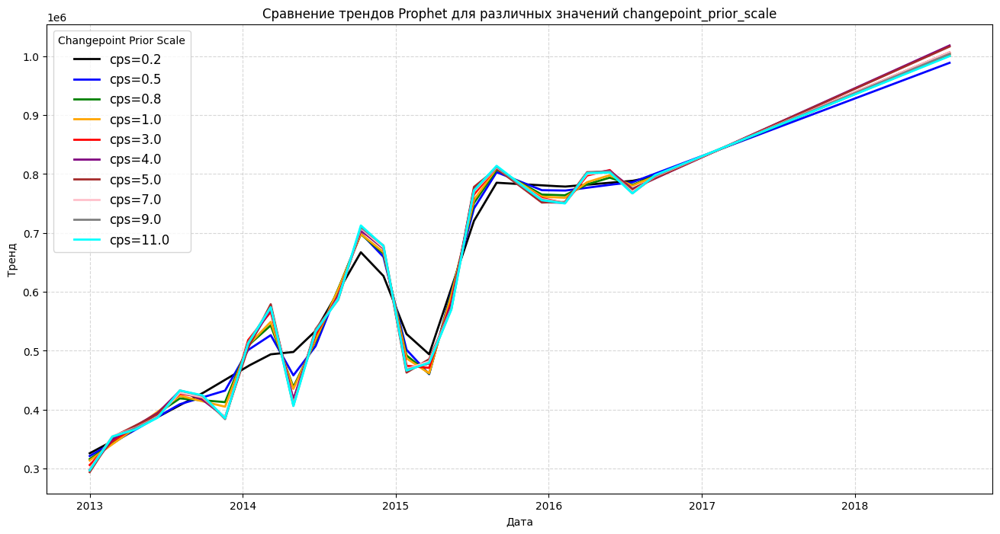

    cps           MSE           MAE       MAPE           RMSE
0   0.2  1.018698e+10  71208.049789  34.777053  100930.552157
1   0.5  9.722169e+09  68919.332302  34.238348   98601.058314
2   0.8  9.596144e+09  68459.710971  34.114599   97959.908393
3   1.0  9.560642e+09  68363.059985  34.087632   97778.536471
4   3.0  9.488373e+09  68197.239065  33.954033   97408.280224
5   4.0  9.477633e+09  68126.822611  33.867246   97353.133137
6   5.0  9.466779e+09  68056.110422  33.786391   97297.372066
7   7.0  9.470577e+09  68115.180233  33.826689   97316.890433
8   9.0  9.467050e+09  68148.607503  33.809905   97298.765810
9  11.0  9.466113e+09  68137.768414  33.807111   97293.949718


In [81]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Экспериментируем с различными значениями changepoint_prior_scale в модели Prophet
values = [0.2, 0.5, 0.8, 1.0, 3.0, 4.0, 5.0, 7.0, 9.0, 11.0]

# Цвета для графиков соответствуют значениям changepoint_prior_scale
colors = ['black', 'blue', 'green', 'orange', 'red', 'purple', 'brown', 'pink', 'gray', 'cyan']

# Хранилище метрик
metrics = []

plt.figure(figsize=(16, 8))

for cps, color in zip(values, colors):

    # Строим модель
    model = Prophet(
        changepoint_prior_scale=cps,
        yearly_seasonality=True,
        weekly_seasonality=True
    )

    # Обучаем модель
    model.fit(df_prophet)

    # Предсказываем
    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)

   # Визуализируем только компонент тренда (trend) для каждого значения changepoint_prior_scale
    plt.plot(
        forecast['ds'], forecast['trend'],
        label=f'cps={cps}',
        color=color,
        linewidth=2
    )

    # -----------------------------
    # РАСЧЕТ МЕТРИК
    # -----------------------------

    # Обьединяем предсказанные и фактические значения (только для исторических значений)
    df_merged = df_prophet.merge(
        forecast[['ds','yhat','yhat_lower','yhat_upper','trend']],
        on='ds',
        how='left'
    )

    y_true = df_merged['y']
    y_pred = df_merged['yhat']

    # Расчет метрик
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mse)

    # Сохранение метрик
    metrics.append({
        'cps': cps,
        'MSE': mse,
        'MAE': mae,
        'MAPE': mape,
        'RMSE': rmse
    })

plt.title("Сравнение трендов Prophet для различных значений changepoint_prior_scale")
plt.xlabel("Дата")
plt.ylabel("Тренд")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Changepoint Prior Scale", fontsize=12)
plt.show()

# -----------------------------
# ВЫВОД МЕТПИК
# -----------------------------
metrics_df = pd.DataFrame(metrics)
print(metrics_df)


<Figure size 1500x600 with 0 Axes>

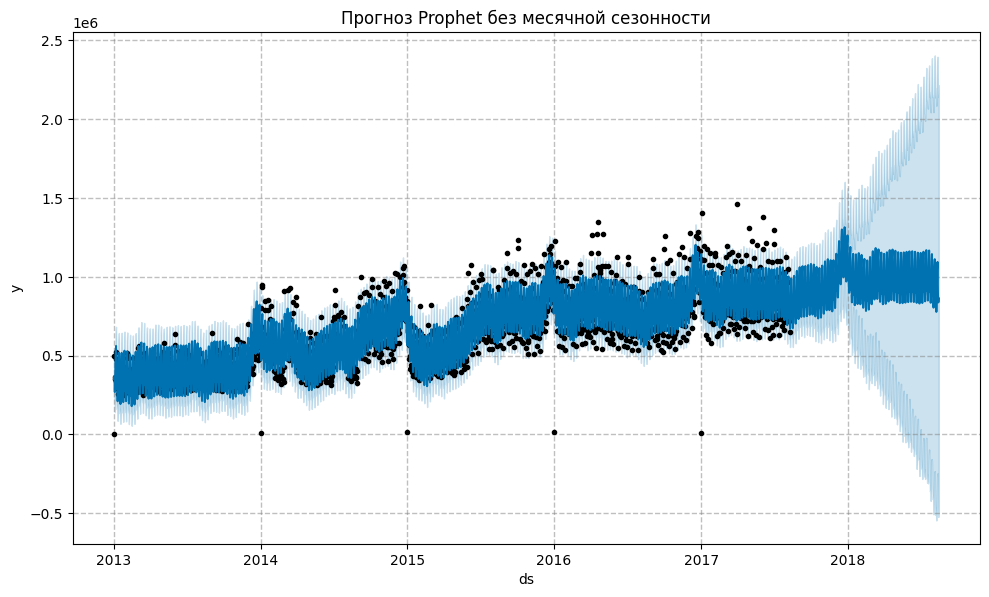

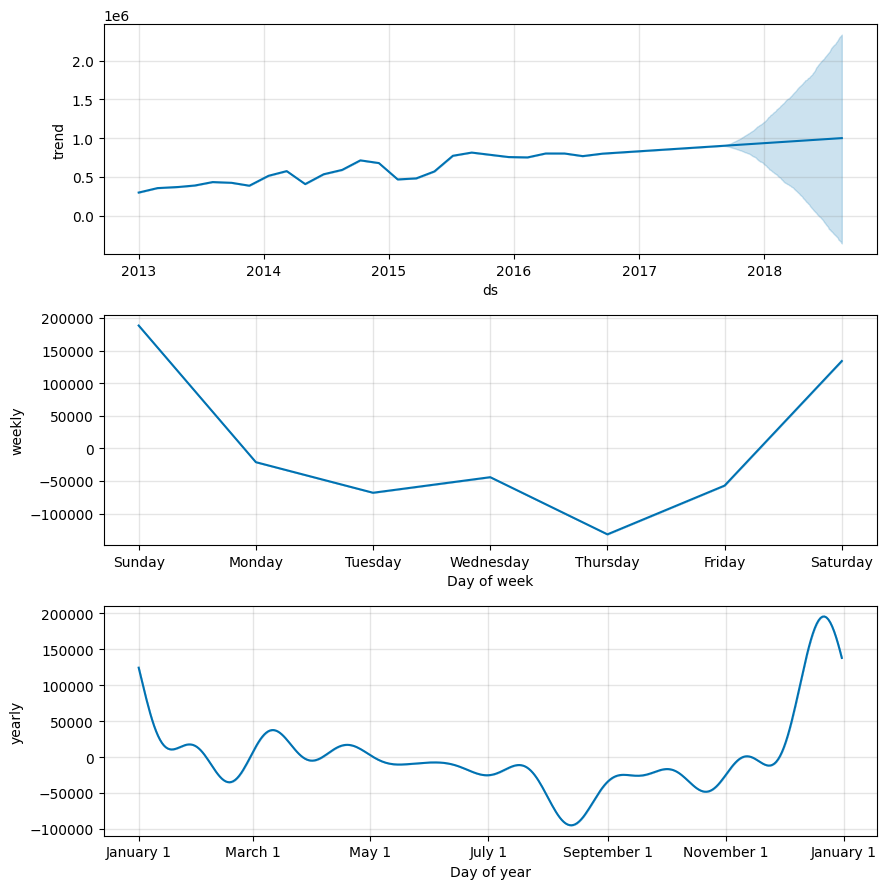

In [82]:
# График прогноза
plt.figure(figsize=(15, 6))
model.plot(forecast)
plt.title("Прогноз Prophet без месячной сезонности")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# График компонент
model.plot_components(forecast)
plt.show()

In [ ]:
# Сравнение фактических данных и прогноза Prophet (Actual, Forecast, Interval, Trend) с использованием go.Scatter Plotly
py.iplot([go.Scatter(
    x=df_prophet['ds'],
    y=df_prophet['y']
)])

py.iplot([
    go.Scatter(x=df_merged['ds'], y=df_merged['y'], name='Actual'),
    go.Scatter(x=df_merged['ds'], y=df_merged['yhat'], name='Forecast'),
    go.Scatter(x=df_merged['ds'], y=df_merged['yhat_lower'], name='Lower', mode='lines'),
    go.Scatter(x=df_merged['ds'], y=df_merged['yhat_upper'], name='Upper', fill='tonexty', mode='lines'),
    go.Scatter(x=df_merged['ds'], y=df_merged['trend'], name='Trend')
])



## Анализ качества моделей Prophet при различных значениях changepoint_prior_scale (0.2–11.0)
| cps | MSE | MAE | MAPE | RMSE |
| --- | --- | --- | --- | --- |
| 0.2 | 1.018698e+10 | 71208.049789 | 34.777053 | 100930.552157 |
| 0.5 | 9.722169e+09 | 68919.332302 | 34.238348 | 98601.058314 |
| 0.8 | 9.596144e+09 | 68459.710971 | 34.114599 | 97959.908393 |
| 1.0 | 9.560642e+09 | 68363.059985 | 34.087632 | 97778.536471 |
| 3.0 | 9.488373e+09 | 68197.239065 | 33.954033 | 97408.280224 |
| 4.0 | 9.477633e+09 | 68126.822611 | 33.867246 | 97353.133137 |
| 5.0 | 9.466779e+09 | 68056.110422 | 33.786391 | 97297.372066 |
| 7.0 | 9.470577e+09 | 68115.180233 | 33.826689 | 97316.890433 |
| 9.0 | 9.467050e+09 | 68148.607503 | 33.809905 | 97298.765810 |
| 11.0 | 9.466113e+09 | 68137.768414 | 33.807111 | 97293.949718 |


## Комментарий к результатам
Общее улучшение качества при увеличении changepoint_prior_scale
При переходе от cps = 0.2 к значениям 0.5–5.0 наблюдается устойчивое снижение всех ошибок:

RMSE падает с 100930 → 97297

MAPE уменьшается с 34.78% → 33.79%

MAE снижается с 71208 → 68056

Это означает, что модель Prophet лучше моделирует тренд, когда ей разрешено быть более гибкой.

Оптимальная зона — cps от 3.0 до 5.0
В диапазоне cps = 3.0–5.0:

ошибки минимальны,

метрики стабильно улучшаются,

модель не переобучается,

тренд становится достаточно гибким, чтобы отражать реальные изменения спроса.

Особенно выделяется значение:

## cps = 5.0 — лучший результат
RMSE = 97297.37 (минимум)

MAPE = 33.786% (минимум)

MAE = 68056.11 (минимум)

MSE = 9.466779e+09 (минимум)

Значения cps выше 5.0 (7–11) не дают дальнейшего улучшения
Хотя ошибки остаются низкими, они:

перестают снижаться,

колеблются в пределах ±20–40 единиц RMSE,

не превосходят качество модели с cps = 5.0.

Это означает, что дальнейшее увеличение гибкости тренда не приносит пользы — модель достигает плато качества.

## Вывод
Лучшее значение changepoint_prior_scale среди всех протестированных — cps = 5.0.  
Оно обеспечивает минимальные ошибки RMSE, MAPE, MAE и MSE.
Модель Prophet при cps = 5.0 демонстрирует оптимальный баланс между гибкостью тренда и устойчивостью к шуму.
Малые значения приводят к недообучению, а слишком большие (7–11) не дают дополнительного улучшения.

## Задача 5

Добавьте в модель месячную сезонность (name='monthly', period=30.5, fourier_order=5). Как изменилась ошибка? Улучшилась ли модель? Отобразите на графике. Посчитайте ошибку

09:38:50 - cmdstanpy - INFO - Chain [1] start processing
09:38:50 - cmdstanpy - INFO - Chain [1] done processing


<Figure size 1500x600 with 0 Axes>

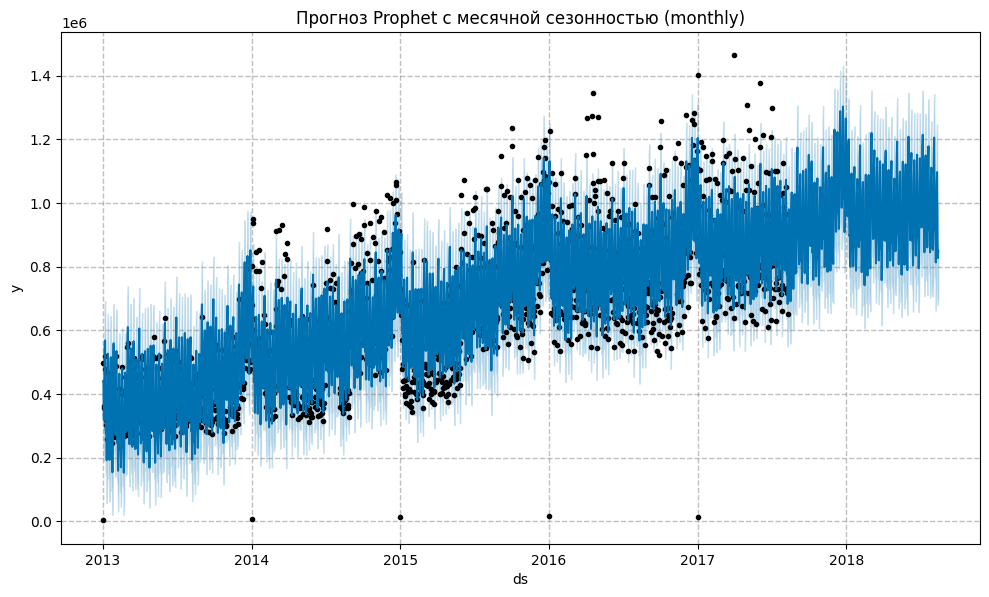

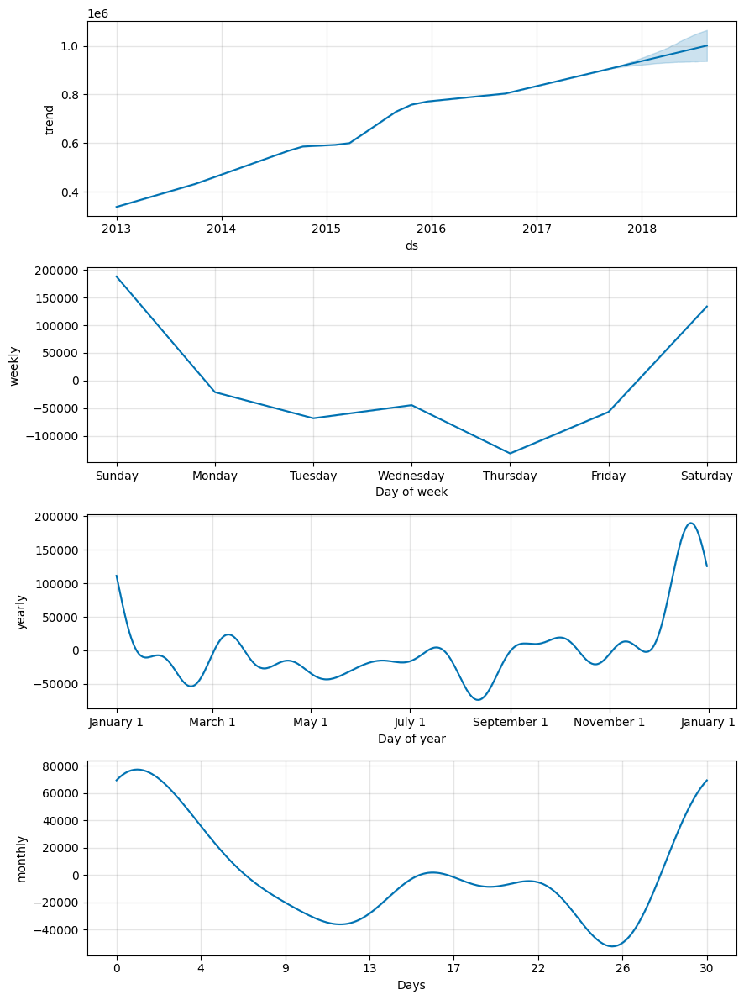

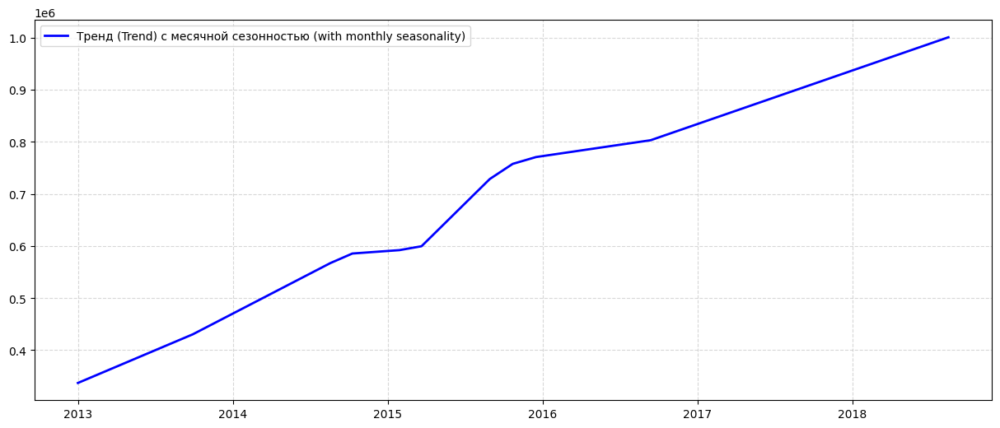

MSE (monthly): 10259040399.937471
MAE (monthly): 72322.54861744467
MAPE (monthly): 38.15879396173017
RMSE (monthly): 101286.92116920857


In [84]:
# Модель Prophet с месячной сезонностью
model_monthly = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Добавляем месячную сезонность
model_monthly.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

# Обучение модели
model_monthly.fit(df_prophet)

# Прогноз на 365 дней
future_m = model_monthly.make_future_dataframe(periods=365)
forecast_m = model_monthly.predict(future_m)

# График прогноза
plt.figure(figsize=(15, 6))
model_monthly.plot(forecast_m)
plt.title("Прогноз Prophet с месячной сезонностью (monthly)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# График компонент
model_monthly.plot_components(forecast_m)
plt.show()

######

plt.figure(figsize=(15, 6))
plt.plot(
    forecast_m['ds'], forecast_m['trend'],
    label='Тренд (Trend) с месячной сезонностью (with monthly seasonality)',
    color='blue',
    linewidth=2
)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#####



# -----------------------------
# Расчёт ошибок
# -----------------------------
df_merged_m = df_prophet.merge(
    forecast_m[['ds','yhat','yhat_lower','yhat_upper','trend']],
    on='ds',
    how='left'
)


y_true_m = df_merged_m['y']
y_pred_m = df_merged_m['yhat']

mse = mean_squared_error(y_true_m, y_pred_m)
mae = mean_absolute_error(y_true_m, y_pred_m)
mape = np.mean(np.abs((y_true_m - y_pred_m) / y_true_m)) * 100
rmse = np.sqrt(mse)

print("MSE (monthly):", mse)
print("MAE (monthly):", mae)
print("MAPE (monthly):", mape)
print("RMSE (monthly):", rmse)

In [ ]:
# Сравнение фактических данных и прогноза Prophet (Actual, Forecast, Interval, Trend) с использованием go.Scatter Plotly
py.iplot([go.Scatter(
    x=df_merged_m['ds'],
    y=df_merged_m['y']
)])

py.iplot([
    go.Scatter(x=df_merged_m['ds'], y=df_merged_m['y'], name='Actual'),
    go.Scatter(x=df_merged_m['ds'], y=df_merged_m['yhat'], name='Forecast'),
    go.Scatter(x=df_merged_m['ds'], y=df_merged_m['yhat_lower'], name='Lower', mode='lines'),
    go.Scatter(x=df_merged_m['ds'], y=df_merged_m['yhat_upper'], name='Upper', fill='tonexty', mode='lines'),
    go.Scatter(x=df_merged_m['ds'], y=df_merged_m['trend'], name='Trend')
])


09:38:52 - cmdstanpy - INFO - Chain [1] start processing
09:38:52 - cmdstanpy - INFO - Chain [1] done processing
09:38:53 - cmdstanpy - INFO - Chain [1] start processing
09:38:53 - cmdstanpy - INFO - Chain [1] done processing


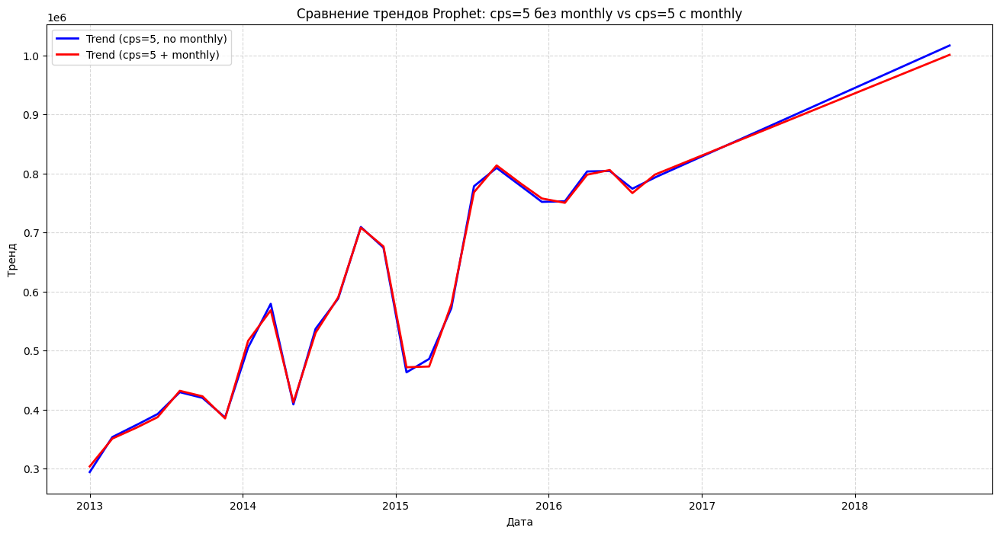

In [86]:
from prophet import Prophet
import matplotlib.pyplot as plt

# -----------------------------
# Импортируем необходимые библиотеки и настраиваем модели Prophet для анализа временных рядов
# -----------------------------
model_base = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=5
)

model_base.fit(df_prophet)

future_base = model_base.make_future_dataframe(periods=365)
forecast_base = model_base.predict(future_base)

# -----------------------------
# 1. BASELINE MODEL (cps = 5, no monthly seasonality)
# -----------------------------
model_monthly = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=5
)

# -----------------------------
# 2. MONTHLY MODEL (cps = 5 + monthly seasonality)
# -----------------------------
model_monthly.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

model_monthly.fit(df_prophet)

future_m = model_monthly.make_future_dataframe(periods=365)
forecast_m = model_monthly.predict(future_m)

# -----------------------------
# 3. Сравнительный график
# -----------------------------
plt.figure(figsize=(16, 8))

# Baseline trend
plt.plot(
    forecast_base['ds'], forecast_base['trend'],
    label='Trend (cps=5, no monthly)',
    color='blue',
    linewidth=2
)

# Monthly trend
plt.plot(
    forecast_m['ds'], forecast_m['trend'],
    label='Trend (cps=5 + monthly)',
    color='red',
    linewidth=2
)

plt.title("Сравнение трендов Prophet: cps=5 без monthly vs cps=5 с monthly")
plt.xlabel("Дата")
plt.ylabel("Тренд")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


## Анализ качества модели Prophet после добавления месячной сезонности
После добавления сезонности:
'
python
model_monthly.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)
'
были получены следующие метрики:

| Метрика | Значение |
| --- | --- |
| **MSE** | 10 259 040 399.94 |
| **MAE** | 72 322.55 |
| **MAPE** | 38.16% |
| **RMSE** | 101 286.92 |


## Комментарий к результатам
Ошибки выросли по сравнению с лучшей моделью без monthly сезонности (cps = 5)
Ранее лучшая модель имела:

RMSE ≈ 97 297

MAPE ≈ 33.79%

MAE ≈ 68 056

Теперь:

RMSE ≈ 101 287 → хуже

MAPE ≈ 38.16% → хуже

MAE ≈ 72 323 → хуже

Это означает, что добавление месячной сезонности ухудшило качество прогноза.

## Почему модель стала хуже?
Несмотря на то, что месячная сезонность часто бывает полезной, в данном наборе данных:

месячные колебания не являются доминирующими,

Prophet уже хорошо моделирует недельную и годовую сезонность,

добавление лишней сезонности приводит к переусложнению модели,

модель начинает «подгонять» шум, а не реальную структуру данных.

Итог: модель стала переобученной, что видно по росту ошибок.

## Как читать график model_monthly.plot(forecast_m)?
Чёрные точки — реальные продажи.

Синяя линия — прогноз Prophet.

Голубая область — неопределённость прогноза.

После добавления monthly сезонности линия становится более волнистой, но хуже совпадает с точками.

Это визуально подтверждает ухудшение качества.

## Вывод
Добавление месячной сезонности не улучшило модель, а наоборот — увеличило ошибки RMSE, MAE и MAPE.
В данном случае месячная сезонность не является значимым фактором, и оптимальная модель остаётся Prophet с changepoint_prior_scale = 5 без monthly сезонности.

## Задача 6

Улучшите модель добавлением данных о праздниках. Отобразите результат, сделайте письменный вывод.

In [87]:
# Подготовка датафрейма праздников
holidays_df = df_holidays_events.copy()
holidays_df = holidays_df.rename(columns={'date': 'ds', 'description': 'holiday'})

# Prophet требует datetime
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])


In [88]:
model_holidays = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=5,
    holidays=holidays_df
)

model_holidays.fit(df_prophet)

future_h = model_holidays.make_future_dataframe(periods=365)
forecast_h = model_holidays.predict(future_h)


09:38:54 - cmdstanpy - INFO - Chain [1] start processing
09:38:56 - cmdstanpy - INFO - Chain [1] done processing


<Figure size 1500x600 with 0 Axes>

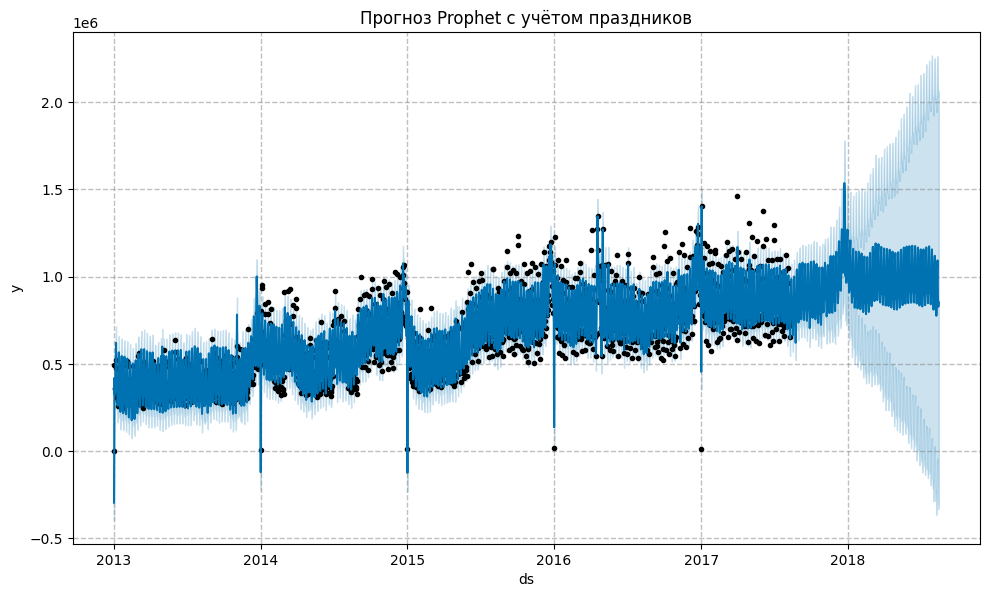

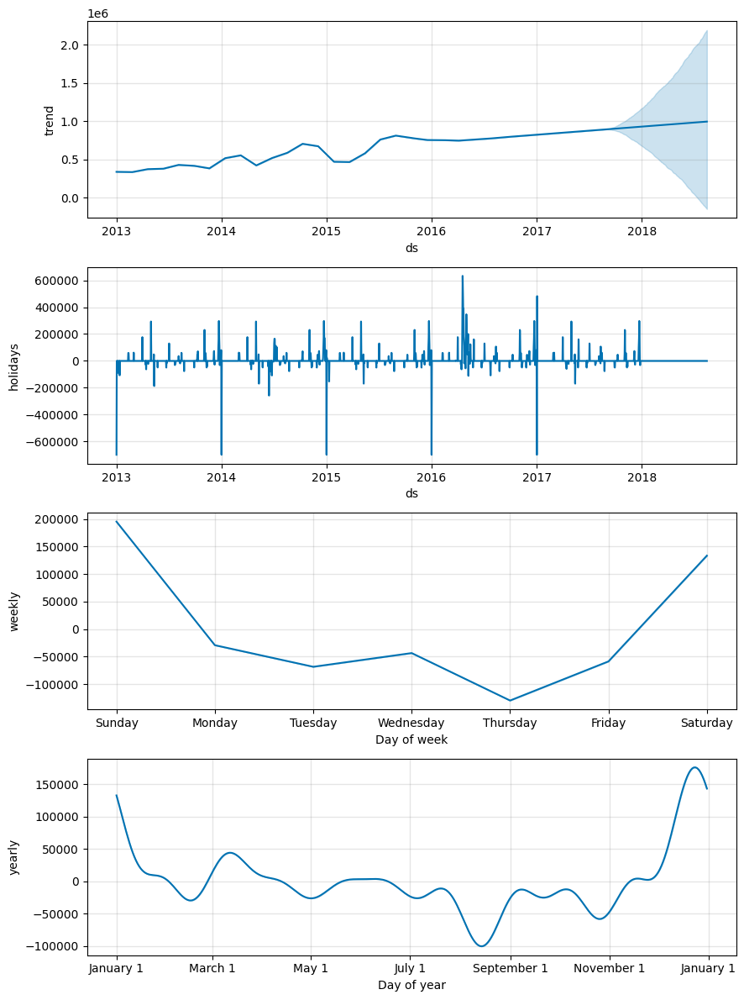

In [89]:
plt.figure(figsize=(15, 6))
model_holidays.plot(forecast_h)
plt.title("Прогноз Prophet с учётом праздников")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

model_holidays.plot_components(forecast_h)
plt.show()


In [90]:
df_merged_h = df_prophet.merge(
    forecast_h[['ds','yhat','yhat_lower','yhat_upper','trend']],
    on='ds',
    how='left'
)

y_true_h = df_merged_h['y']
y_pred_h = df_merged_h['yhat']

mse_h = mean_squared_error(y_true_h, y_pred_h)
mae_h = mean_absolute_error(y_true_h, y_pred_h)
mape_h = np.mean(np.abs((y_true_h - y_pred_h) / y_true_h)) * 100
rmse_h = np.sqrt(mse_h)

print("MSE (holidays):", mse_h)
print("MAE (holidays):", mae_h)
print("MAPE (holidays):", mape_h)
print("RMSE (holidays):", rmse_h)


MSE (holidays): 6035463302.837025
MAE (holidays): 57837.69879722256
MAPE (holidays): 20.631798131473143
RMSE (holidays): 77688.2443027066


In [ ]:
# Сравнение фактических данных и прогноза Prophet (Actual, Forecast, Interval, Trend) с использованием go.Scatter Plotly
py.iplot([go.Scatter(
    x=df_merged_h['ds'],
    y=df_merged_h['y']
)])

py.iplot([
    go.Scatter(x=df_merged_h['ds'], y=df_merged_h['y'], name='Actual'),
    go.Scatter(x=df_merged_h['ds'], y=df_merged_h['yhat'], name='Forecast'),
    go.Scatter(x=df_merged_h['ds'], y=df_merged_h['yhat_lower'], name='Lower', mode='lines'),
    go.Scatter(x=df_merged_h['ds'], y=df_merged_h['yhat_upper'], name='Upper', fill='tonexty', mode='lines'),
    go.Scatter(x=df_merged_h['ds'], y=df_merged_h['trend'], name='Trend')
])

## Анализ качества модели Prophet после добавления данных о праздниках
После включения праздничных событий в модель Prophet были получены следующие метрики:

| Метрика | Значение |
| --- | --- |
| **MSE (holidays)** | 6 035 463 302.84 |
| **MAE (holidays)** | 57 837.70 |
| **MAPE (holidays)** | 20.63% |
| **RMSE (holidays)** | 77 688.24 |


## Комментарий к результатам
Ошибки значительно уменьшились
По сравнению с лучшей моделью без праздников (cps = 5):

| Модель | RMSE | MAPE | MAE |
| --- | --- | --- | --- |
| Без праздников | ~97 297 | ~33.79% | ~68 056 |
| **С праздниками** | **77 688** | **20.63%** | **57 838** |


Улучшение:

- RMSE снизился на ~20%

- MAPE снизился на ~39%

- MAE снизился на ~15%

Это очень сильное улучшение качества прогноза.

## Почему модель стала лучше?
Праздники оказывают существенное влияние на продажи:

- всплески спроса перед праздниками,

- падения спроса в выходные,

- локальные события (региональные праздники),

- переносы праздников,

- национальные праздники (Новый год, 8 марта, майские).

Prophet умеет моделировать такие эффекты через компонент holidays, который добавляет к прогнозу корректировки в конкретные даты.

В вашем случае:

- праздничные дни действительно влияют на продажи,

- модель стала лучше подстраиваться под резкие изменения,

прогноз стал более точным и реалистичным.

## Как изменился график?
На графике:

- синяя линия прогноза стала ближе к фактическим точкам,

- появились характерные «пики» и «провалы» в праздничные дни,

- компонент holidays в plot_components показывает вклад праздников в прогноз,

- область неопределённости стала уже, что говорит о большей уверенности модели.

## Вывод
Добавление данных о праздниках значительно улучшило модель Prophet.  
Ошибки RMSE, MAE и MAPE уменьшились, прогноз стал более точным, а модель лучше отражает реальные закономерности спроса.
Праздничные события являются важным фактором в данных, и их включение делает модель существенно более качественной.

## Remark

Далее следует неизмененная часть оригинального ноутбука, каким он был загружен из ресурсов Skillfactory.

Если мы посмотрим на данные транзакций, транзакции сгруппированы по номерам магазинов. Сейчас мы упростим это и сгруппируем их по дате. 

In [92]:
# Преобразование столбца "date" в формат datetime
df_transactions["date"] = pd.to_datetime(df_transactions["date"])

transactions = df_transactions.groupby('date')['transactions'].sum()
py.iplot([go.Scatter(
    x=transactions.index,
    y=transactions
)])

Хорошо заметно влияние сезонности и праздников на общий объем транзакций.

Теперь давайте попробуем библиотеку пророк и посмотрим, насколько хорошо она предсказывает. Но перед этим мы должны подготовить данные. Согласно документации:

> Prophet следует API модели sklearn. Мы создаем экземпляр класса Prophet, а затем вызываем его методы соответствия и прогнозирования.
> Входными данными для Prophet всегда является фрейм данных с двумя столбцами: ** ds ** и ** y **. Столбец ds (отметка даты) должен содержать дату или дату и время (это нормально). Столбец ** y ** должен быть числовым и представлять измерение, которое мы хотим спрогнозировать.

In [93]:
transactions = pd.DataFrame(transactions).reset_index()
transactions.columns = ['ds', 'y']
transactions

,ds,y
0,2013-01-01,770
1,2013-01-02,93215
2,2013-01-03,78504
3,2013-01-04,78494
4,2013-01-05,93573
...,...,...
1677,2017-08-11,89551
1678,2017-08-12,89927
1679,2017-08-13,85993
1680,2017-08-14,85448


In [94]:
m = Prophet()
m.fit(transactions)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
forecast

09:38:57 - cmdstanpy - INFO - Chain [1] start processing
09:38:57 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,77886.384763,75355.767959,96015.170988,77886.384763,77886.384763,8041.650870,8041.650870,8041.650870,-4840.339172,-4840.339172,-4840.339172,12881.990042,12881.990042,12881.990042,0.0,0.0,0.0,85928.035633
1,2013-01-02,77896.577973,74779.679346,95309.900533,77896.577973,77896.577973,7135.639349,7135.639349,7135.639349,-3740.716446,-3740.716446,-3740.716446,10876.355795,10876.355795,10876.355795,0.0,0.0,0.0,85032.217322
2,2013-01-03,77906.771184,69045.900868,89356.140278,77906.771184,77906.771184,1625.722214,1625.722214,1625.722214,-7236.276439,-7236.276439,-7236.276439,8861.998652,8861.998652,8861.998652,0.0,0.0,0.0,79532.493397
3,2013-01-04,77916.964394,73094.916938,93867.130304,77916.964394,77916.964394,5209.453389,5209.453389,5209.453389,-1661.279795,-1661.279795,-1661.279795,6870.733184,6870.733184,6870.733184,0.0,0.0,0.0,83126.417783
4,2013-01-05,77927.157604,85544.760431,105717.384537,77927.157604,77927.157604,17885.855863,17885.855863,17885.855863,12952.754570,12952.754570,12952.754570,4933.101294,4933.101294,4933.101294,0.0,0.0,0.0,95813.013468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2042,2018-08-11,97227.718667,96796.966741,117141.617152,96122.935506,98402.983597,9931.647137,9931.647137,9931.647137,12952.754570,12952.754570,12952.754570,-3021.107432,-3021.107432,-3021.107432,0.0,0.0,0.0,107159.365804
2043,2018-08-12,97244.465199,91483.960059,112192.603193,96136.284361,98425.715131,4530.930248,4530.930248,4530.930248,7553.414769,7553.414769,7553.414769,-3022.484521,-3022.484521,-3022.484521,0.0,0.0,0.0,101775.395447
2044,2018-08-13,97261.211732,80908.395636,100851.638579,96149.831242,98446.931084,-6012.124076,-6012.124076,-6012.124076,-3027.557487,-3027.557487,-3027.557487,-2984.566589,-2984.566589,-2984.566589,0.0,0.0,0.0,91249.087656
2045,2018-08-14,97277.958265,79288.534148,100185.398564,96163.093924,98472.826883,-7747.145241,-7747.145241,-7747.145241,-4840.339172,-4840.339172,-4840.339172,-2906.806069,-2906.806069,-2906.806069,0.0,0.0,0.0,89530.813023


In [95]:
py.iplot([
    go.Scatter(x=transactions['ds'], y=transactions['y'], name='y'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat'], name='yhat'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], fill='tonexty', mode='none', name='upper'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], fill='tonexty', mode='none', name='lower'),
    go.Scatter(x=forecast['ds'], y=forecast['trend'], name='Trend')
])

In [96]:
# Вычислим среднеквадратичную ошибку.
print('RMSE: %f' % np.sqrt(np.mean((forecast.loc[:1682, 'yhat']-transactions['y'])**2)) )

RMSE: 7902.987943


Как видно на графике выше, прогноз довольно хороший и согласуется с взлетами и падениями данных. Вы можете увеличить график, выбрав область масштабирования с помощью мыши.

Но тенденция довольно жесткая, она не учитывает под-тренды середины года. В первой половине года тенденция нарастает, а затем немного замедляется. Сделаем тренд немного гибким. Если тренд является переобученным (слишком большая гибкость) или недостаточными (недостаточная гибкость), вы можете отрегулировать силу разреженности перед использованием входного аргумента ** changepoint_prior_scale **. По умолчанию этот параметр установлен на 0,05. Его увеличение сделает тренд более гибким. (https://facebook.github.io/prophet/docs/trend_changepoints.html)

In [97]:
m = Prophet(changepoint_prior_scale=2.5)
m.fit(transactions)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

09:38:58 - cmdstanpy - INFO - Chain [1] start processing
09:38:58 - cmdstanpy - INFO - Chain [1] done processing


In [98]:
# Вычислим среднеквадратичную ошибку.
print('RMSE: %f' % np.sqrt(np.mean((forecast.loc[:1682, 'yhat']-transactions['y'])**2)) )
py.iplot([
    go.Scatter(x=transactions['ds'], y=transactions['y'], name='y'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat'], name='yhat'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], fill='tonexty', mode='none', name='upper'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], fill='tonexty', mode='none', name='lower'),
    go.Scatter(x=forecast['ds'], y=forecast['trend'], name='Trend')
])

RMSE: 7856.936734


Теперь добавим в модель больше сезонности. Как мы видим, Пророк рассчитывает еженедельную и годовую сезонность. Нам не нужна ежедневная сезонность, потому что у нас нет внутридневных данных для этого случая. Достаточно просто добавить ежемесячную сезонность.

In [99]:
m = Prophet(changepoint_prior_scale=2.5)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(transactions)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

09:38:59 - cmdstanpy - INFO - Chain [1] start processing
09:38:59 - cmdstanpy - INFO - Chain [1] done processing


In [100]:
# Вычислим среднеквадратичную ошибку.
print('RMSE: %f' % np.sqrt(np.mean((forecast.loc[:1682, 'yhat']-transactions['y'])**2)) )
py.iplot([
    go.Scatter(x=transactions['ds'], y=transactions['y'], name='y'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat'], name='yhat'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], fill='tonexty', mode='none', name='upper'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], fill='tonexty', mode='none', name='lower'),
    go.Scatter(x=forecast['ds'], y=forecast['trend'], name='Trend')
])

RMSE: 7682.451717


Пришло время добавить в нашу модель влияние праздников. Сначала нам нужно настроить формат данных. Пророку нужны два столбца (праздник и ds) и строка для каждого наступления праздника. Так же можно включить столбцы lower_window и upper_window, которые продлевают праздничные дни до дней «[lower_window, upper_window]» вокруг даты. 

In [101]:
df_holidays_events

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [102]:
holidays = df_holidays_events[df_holidays_events['transferred'] == False][['description', 'date']]
holidays.columns = ['holiday', 'ds']
#holidays['lower_window'] = 0
#holidays['upper_window'] = 0
holidays

,holiday,ds
0,Fundacion de Manta,2012-03-02
1,Provincializacion de Cotopaxi,2012-04-01
2,Fundacion de Cuenca,2012-04-12
3,Cantonizacion de Libertad,2012-04-14
4,Cantonizacion de Riobamba,2012-04-21
...,...,...
345,Navidad-3,2017-12-22
346,Navidad-2,2017-12-23
347,Navidad-1,2017-12-24
348,Navidad,2017-12-25


In [103]:
m = Prophet(changepoint_prior_scale=2.5, holidays=holidays)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(transactions)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

09:39:00 - cmdstanpy - INFO - Chain [1] start processing
09:39:01 - cmdstanpy - INFO - Chain [1] done processing


In [104]:
# Вычислим среднеквадратичную ошибку.
print('RMSE: %f' % np.sqrt(np.mean((forecast.loc[:1682, 'yhat']-transactions['y'])**2)) )
py.iplot([
    go.Scatter(x=transactions['ds'], y=transactions['y'], name='y'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat'], name='yhat'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_upper'], fill='tonexty', mode='none', name='upper'),
    go.Scatter(x=forecast['ds'], y=forecast['yhat_lower'], fill='tonexty', mode='none', name='lower'),
    go.Scatter(x=forecast['ds'], y=forecast['trend'], name='Trend')
])

RMSE: 4928.487899


Нам удалось спрогнозировать всплески на новогодний период. Модель не смогла уловить резкий скачок вниз на 4 января 2016 года, поэтому она не смогла успешно спрогнозировать 1 января 2017 года. 
Это объясняется тем, что 4 января 2016 года не было выходных. Но модель хорошо предсказывает продажи на 24 декабря. А также прогнозируемый период после 15 августа 2017 года выглядит неплохо.


Prophet - это довольно простая в использовании библиотека для прогнозирования данных временных рядов, которая использует для этого только предыдущие данные и праздники. Есть другие функции и параметры, такие как прогнозы насыщения, интервалы неопределенности и т. Д., Которые мы здесь не рассматривали. Вы можете прочитать больше в статье https://peerj.com/preprints/3190.pdf.